import các thư viện

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

đọc dữ liệu từ dataset

In [ ]:
white_wine_df = pd.read_csv("..\\..\\dataset\\winequality-white.csv", sep=";")

In [ ]:
print(white_wine_df.shape)
white_wine_df.head()
white_wine_df.info()
white_wine_df.describe()

(4898, 12)
<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


OUTLIERS

In [ ]:
Q1 = white_wine_df['alcohol'].quantile(0.25)
Q3 = white_wine_df['alcohol'].quantile(0.75)
IQR = Q3 - Q1

outliers = white_wine_df[(white_wine_df['alcohol'] < Q1 - 1.5*IQR) |
                       (white_wine_df['alcohol'] > Q3 + 1.5*IQR)]

print(outliers)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
142             5.2              0.34         0.00             1.8      0.050   
144             5.2              0.34         0.00             1.8      0.050   
467             8.8              0.46         0.45             2.6      0.065   
588             5.0              0.42         0.24             2.0      0.060   
652            15.9              0.36         0.65             7.5      0.096   
821             4.9              0.42         0.00             2.1      0.048   
1114            5.0              0.40         0.50             4.3      0.046   
1132            7.4              0.36         0.34             1.8      0.075   
1228            5.1              0.42         0.00             1.8      0.044   
1269            5.5              0.49         0.03             1.8      0.044   
1270            5.0              0.38         0.01             1.6      0.048   
1475            5.3         

<Axes: xlabel='quality', ylabel='count'>

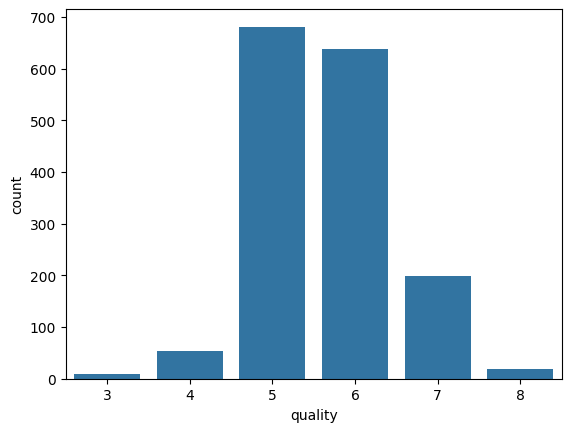

In [ ]:
sns.countplot(x="quality", data=white_wine_df)

<Axes: xlabel='quality', ylabel='count'>

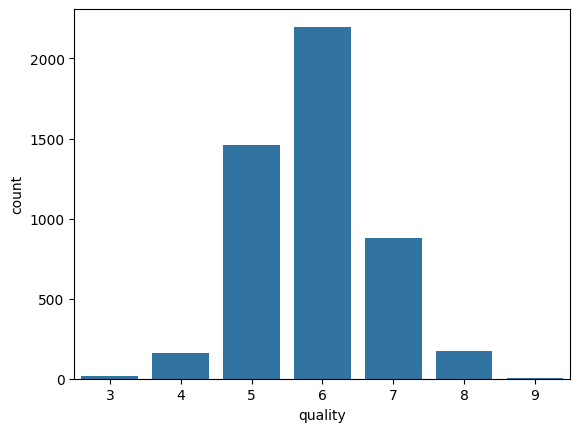

In [ ]:
sns.countplot(x="quality", data=white_wine_df)

In [ ]:
print(white_wine_df['quality'].describe())
print(white_wine_df['quality'].value_counts().sort_index())

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
white_wine_df['quality_group'] = white_wine_df['quality'].apply(
    lambda x: 'Low' if x <= 4 else ('High' if x >= 7 else 'Medium')
)

print(white_wine_df['quality_group'].value_counts())

quality_group
Medium    3655
High      1060
Low        183
Name: count, dtype: int64


data winequality-white

In [ ]:
corr_white = white_wine_df.corr()
corr_white

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881,-0.113663
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718,-0.194723
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729,-0.009209
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631,-0.097577
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189,-0.209934
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104,0.008158
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892,-0.174737
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138,-0.307123
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432,0.099427
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433,0.053678


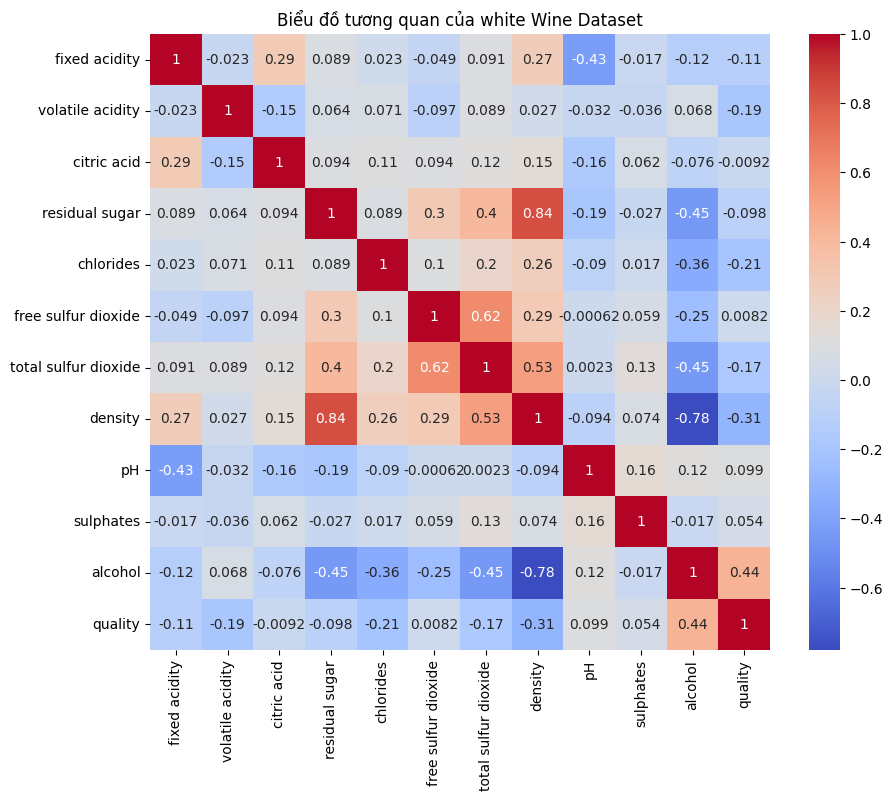

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(corr_white, annot=True, cmap="coolwarm")
plt.title("Biểu đồ tương quan của white Wine Dataset")
plt.show()

In [ ]:
corr_white["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64

In [ ]:


upper_white = corr_white.where(np.triu(np.ones(corr_white.shape), k=1).astype(bool))

high_corr_white = upper_white.stack().reset_index()
high_corr_white.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_white = high_corr_white[abs(high_corr_white['Correlation']) >= 0.5]
print(high_corr_white)

               Feature 1             Feature 2  Correlation
43        residual sugar               density     0.838966
66   free sulfur dioxide  total sulfur dioxide     0.615501
79  total sulfur dioxide               density     0.529881
94               density               alcohol    -0.780138


Kết quả phân tích cho thấy một số cặp biến có tương quan khá mạnh trong dataset white wine.
Residual sugar và density có tương quan dương rất mạnh (r ≈ 0.84), cho thấy khi lượng đường dư trong rượu tăng thì mật độ của rượu cũng có xu hướng tăng.

Free sulfur dioxide và total sulfur dioxide có tương quan dương mạnh (r ≈ 0.62), điều này hợp lý vì total sulfur dioxide bao gồm cả free sulfur dioxide.

Ngoài ra, total sulfur dioxide và density có tương quan dương khá mạnh (r ≈ 0.53), cho thấy khi lượng sulfur dioxide tăng thì mật độ rượu có xu hướng tăng.

Ngược lại, density và alcohol có tương quan âm mạnh (r ≈ -0.78), cho thấy khi nồng độ cồn tăng thì mật độ rượu có xu hướng giảm.


Phân tích tương quan cho thấy alcohol có tương quan dương lớn nhất với quality ở cả hai dataset.
Cụ thể, hệ số tương quan của alcohol với quality là 0.48 trong red wine và 0.44 trong white wine, cho thấy khi nồng độ cồn tăng thì chất lượng rượu có xu hướng tăng ở cả hai loại.
Bên cạnh đó free sulfur dioxide và total sulfur dioxide cũng có sự tương quan với nhau tăng với nhau là 0.66 trong red wine và 0.61 trong white wine 